<a href="https://colab.research.google.com/github/AshrfCode/Data-Mining-and-Machine-Learning/blob/main/lab4_ex1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#import libraries
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["LOKY_MAX_CPU_COUNT"] = "1"
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import silhouette_samples
#import datasets
from sklearn import datasets
from sklearn.model_selection import train_test_split
from scipy.stats import mode
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay

In [ ]:
# %% plot data
#plot the data with colored labels and centroids
def plotData(data, names,labels,col1,col2, labelsType, centroids = np.empty([0,0])):
    #plot the titles
    plt.title(labelsType +  " labels")
    plt.xlabel(names[col1])
    plt.ylabel(names[col2])
    # plot the data with different color for every label and size of 50 pixels
    myPlot =plt.scatter(data[:,col1],data[:,col2],c = labels, s=50)
    nLabels =len(set(labels))
    # plot the centroids if exists in blue and with X marker
    plt.legend(handles=myPlot.legend_elements()[0], labels=range(nLabels))
    if (centroids.any()):
        plt.scatter(centroids[:,col1], centroids[:,col2], c='blue', marker = "x", s=80)
    plt.show(myPlot)

In [ ]:
# %% plot labels
# plot the samples labels
def plotLabels(labels,labelsType):
    xmax=len(labels)
    plt.title("The Iris Dataset " + labelsType + " labels")
    plt.xlabel("Iris sample number")
    plt.ylabel("label")
    plt.bar(range(xmax),labels)
    plt.show()

In [ ]:
# %% vector centroids
# for every label compute the average of every data colomn
def vecCentroids(data,labels):
    # number of different labels
    nLabels=len(set(labels))
    # number of data features - colmons
    nCols = data.shape[1]
    inLabels = labels
    # compute sum and count of every colomn for every label
    sum = np.zeros((nLabels,nCols))
    count = np.zeros((nLabels,nCols))
    for i,elem in enumerate(data):
        sum[inLabels[i]]+=elem
        count[inLabels[i]]+=1
    return(sum/count)

In [ ]:
# %% plot siluette
# Plot the siluette of the samples and the average siluette value
def plotSilluette(silhouetteValues):
    plt.title("The silhouette test plot")
    plt.ylabel("The silhouette values")
    plt.xlabel("The sample#")
    plt.plot(silhouetteValues)
    plt.axis([0,len(silhouetteValues),-1,1])
    plt.hlines(np.average(silhouetteValues), 0, len(silhouetteValues),
               colors='black', linestyles="--")
    plt.hlines(0, 0, len(silhouetteValues), colors='red', linestyles="--")
    plt.show()

In [ ]:
# %%    rearange Labels
# rearange predicted labels
# according to the most common true label
def rearangeLabels(trueLabels,predLabels,k):
    rearangedLabels = np.zeros_like(trueLabels)
    for i in range(k):
        predIs = np.where((i)==predLabels)[0]
        # Get the true labels in the predicted locations
        trueLabelsInLoc = trueLabels[predIs]
        # find the common label
        commonLabel,count = mode(trueLabelsInLoc)
        # put the comon true label in the predicted location
        rearangedLabels[predIs] = commonLabel
    return rearangedLabels

In [ ]:
def ComputeAccuracyAndRecall(trueLabels,predictedLabels):
    classes = set(trueLabels)
    recall = []
    accuracy = []
    for c in classes:
        TP = sum((trueLabels == c) & (predictedLabels == c))
        FP = sum((trueLabels != c) & (predictedLabels == c))
        TN = sum((trueLabels != c) & (predictedLabels != c))
        FN = sum((trueLabels != c) & (predictedLabels == c))
        accuracy+= [(TP+TN)/(TP+FP+TN+FN)]
        recall += [TP / (TP + FN)]
    return(accuracy,recall)

In [ ]:
# %% load and plot
Iris = datasets.load_iris()
data = Iris.data
names = Iris.feature_names
trueLabels = Iris.target # true labeling

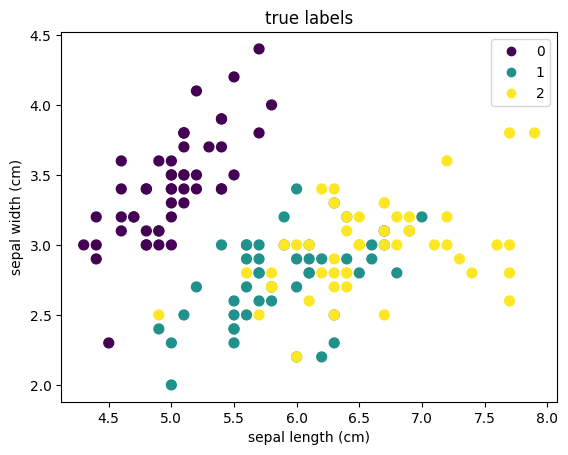

In [ ]:
plotData(data, names,trueLabels,0,1,"true")

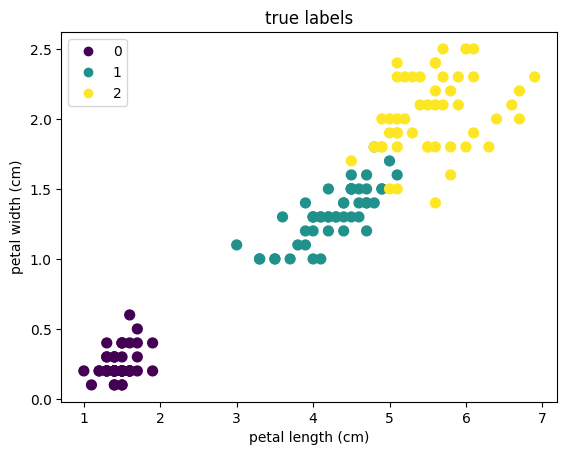

In [ ]:
plotData(data, names,trueLabels,2,3,"true")

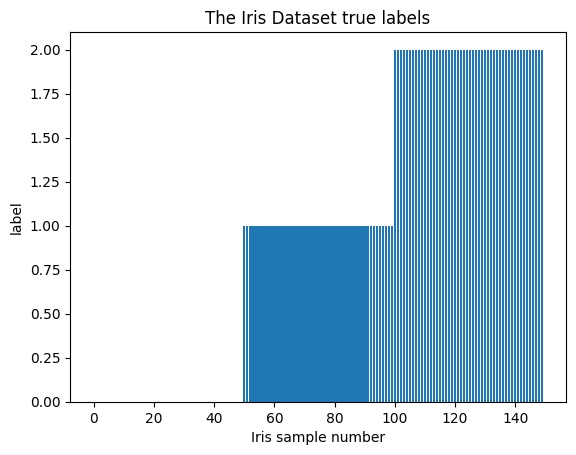

In [ ]:
plotLabels(trueLabels,"true")

In [ ]:
# %% split data
#split data to test and train sets
trainData, testData, trainLabels, testLabels = train_test_split(
    data, trueLabels, test_size = 0.70, stratify=trueLabels)

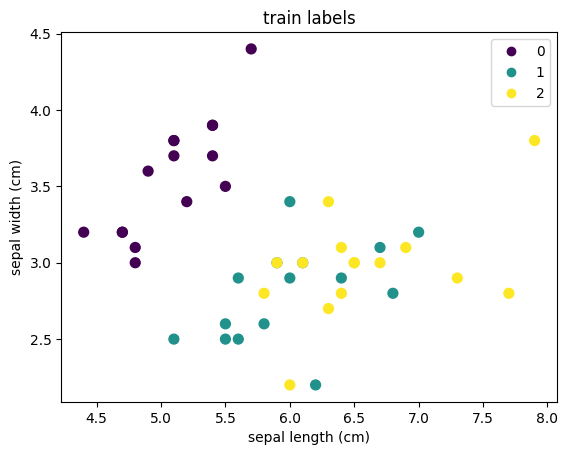

In [ ]:
plotData(trainData, names,trainLabels,0,1,"train")

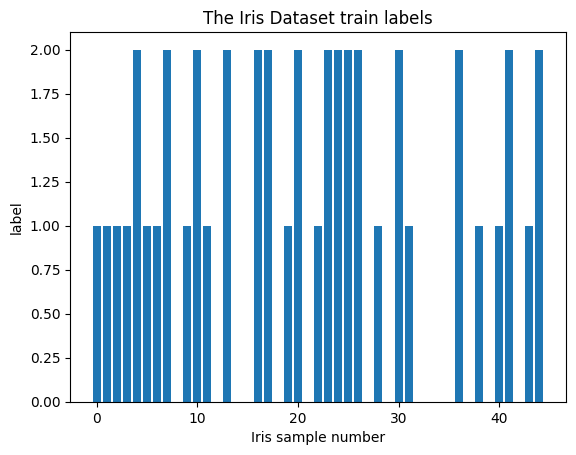

In [ ]:
plotLabels(trainLabels,"train")

In [ ]:
# %% run kmeans
# Run k-means
k=4
kmeans = KMeans(n_clusters = k).fit(trainData)
predLabels = kmeans.predict(testData)
predCentroids = kmeans.cluster_centers_
testCentroids = vecCentroids(testData,testLabels)
predictedLabels = rearangeLabels(testLabels,predLabels,k)

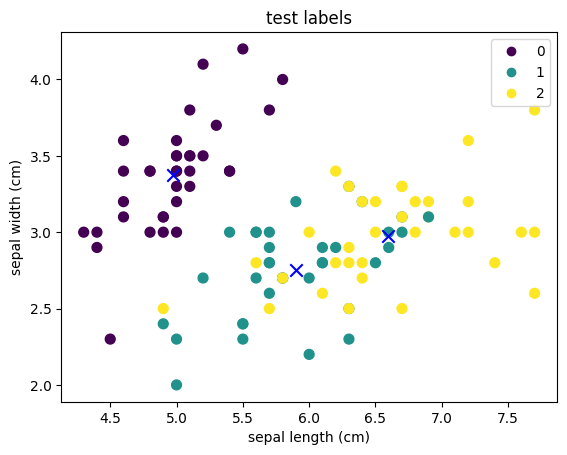

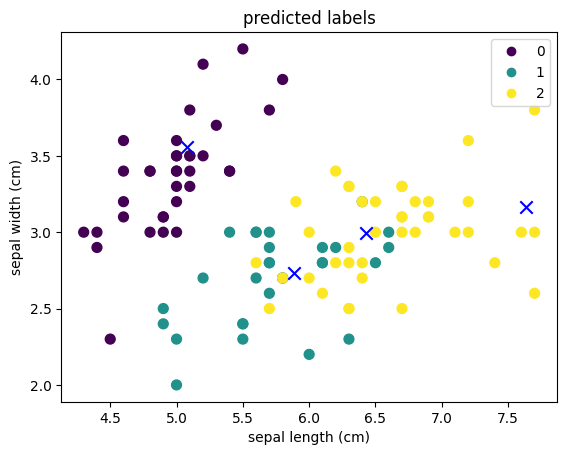

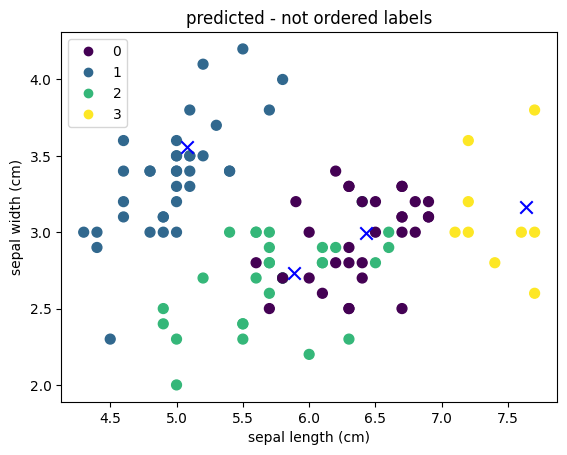

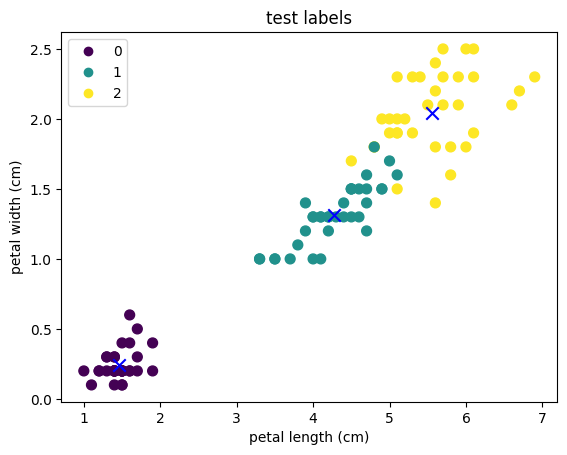

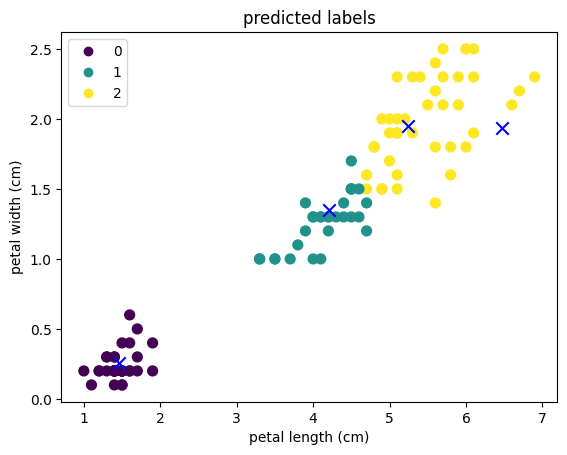

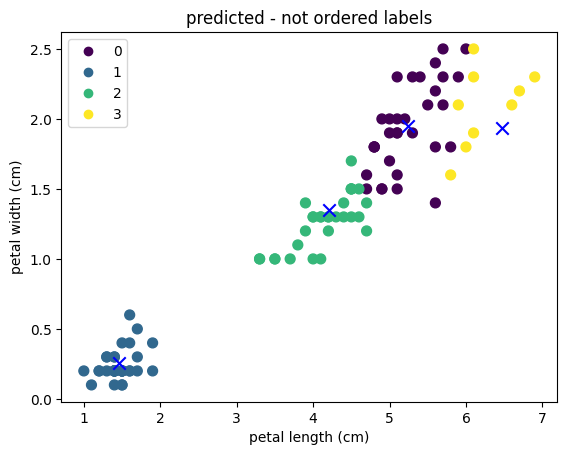

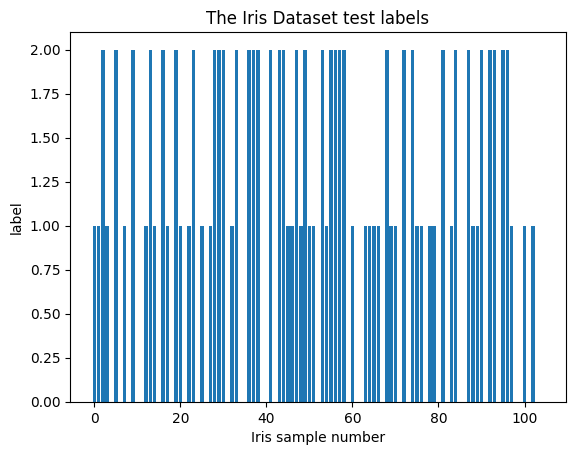

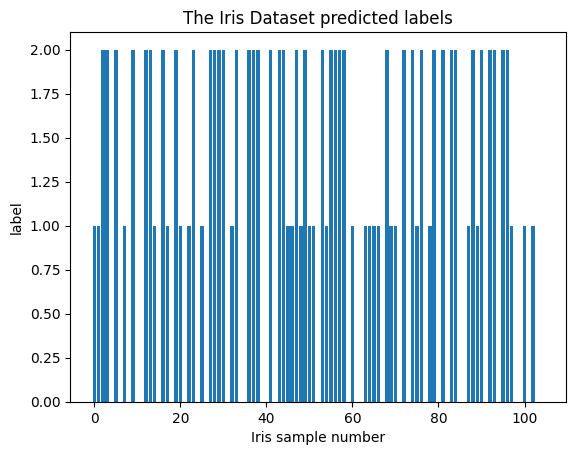

In [ ]:
# Plot the predicted results
plotData(testData, names,testLabels,0,1,"test",testCentroids)
plotData(testData, names,predictedLabels,0,1,"predicted",predCentroids)
plotData(testData, names,predLabels,0,1,"predicted - not ordered",predCentroids)
plotData(testData, names,testLabels,2,3,"test",testCentroids)
plotData(testData, names,predictedLabels,2,3,"predicted",predCentroids)
plotData(testData, names,predLabels,2,3,"predicted - not ordered",predCentroids)
plotLabels(testLabels,"test")
plotLabels(predictedLabels,"predicted")

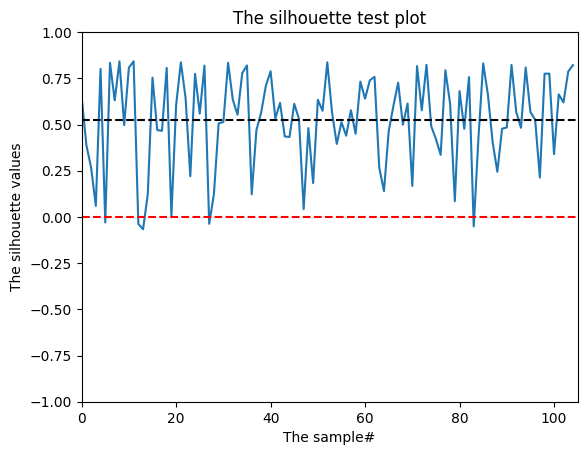

In [ ]:
# %% silhouette and confusion matrix
#plot the silhouette values

silhouetteValues = silhouette_samples(testData, predictedLabels)
plotSilluette(silhouetteValues)

In [ ]:
print("For clusters =", k,
      "The average silhouette_score is: %.2f"  %np.average(silhouetteValues))

For clusters = 4 The average silhouette_score is: 0.53


In [ ]:
confusionMat = confusion_matrix(testLabels, predictedLabels)
print("the confusion matrix is\n",confusionMat)

the confusion matrix is
 [[35  0  0]
 [ 0 28  7]
 [ 0  1 34]]


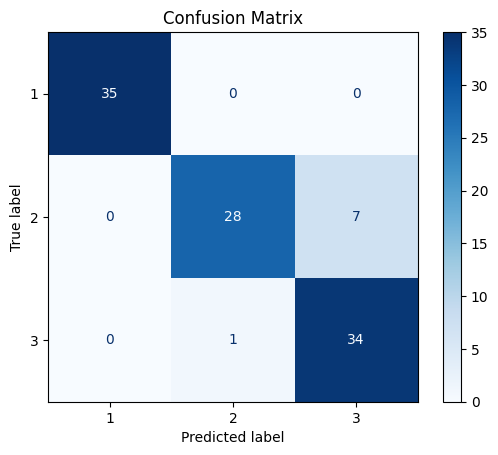

In [ ]:
# Plot the matrix
disp = ConfusionMatrixDisplay(confusionMat, display_labels=range(1,max(np.shape(confusionMat))+1))
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()


In [ ]:
accuracy,recall = ComputeAccuracyAndRecall(testLabels,predictedLabels)

for i in range(len(accuracy)):
   print(f"The accuracy for class {i} is {accuracy[i]:.2f}")
   print(f"The recall for class {i} is {recall[i]:.2f}")

The accuracy for class 0 is 1.00
The recall for class 0 is 1.00
The accuracy for class 1 is 0.98
The recall for class 1 is 0.97
The accuracy for class 2 is 0.87
The recall for class 2 is 0.83


In [ ]:
# Define our two feature subsets
feature_sets = [
    ("First Two Columns (Sepal Dimensions)", [0, 1]),
    ("Last Two Columns (Petal Dimensions)", [2, 3])
]

for name, cols in feature_sets:
    print(f"\n=========================================")
    print(f"Testing on: {name}")
    print(f"=========================================")

    # Slice the data to only include the chosen columns
    train_subset = trainData[:, cols]
    test_subset = testData[:, cols]

    for k in [2, 3, 4]:
        sil_scores, acc_scores, rec_scores = [], [], []

        # Run 3 times to average out random initialization
        for _ in range(3):
            kmeans = KMeans(n_clusters = k).fit(train_subset)
            predLabels = kmeans.predict(test_subset)

            # Rearrange labels to match the true labels as best as possible
            predictedLabels = rearangeLabels(testLabels, predLabels, k)

            # Calculate metrics
            avg_sil = np.average(silhouette_samples(test_subset, predictedLabels))
            acc, rec = ComputeAccuracyAndRecall(testLabels, predictedLabels)

            sil_scores.append(avg_sil)
            acc_scores.append(np.average(acc))
            rec_scores.append(np.average(rec))

        print(f"\n--- Results for k={k} ---")
        print(f"Avg Silhouette: {np.average(sil_scores):.3f}")
        print(f"Avg Accuracy:   {np.average(acc_scores):.3f}")
        print(f"Avg Recall:     {np.average(rec_scores):.3f}")

In [ ]:
print("--- Question 3: Centroids and Distances ---")

# 1. Calculate centroids
true_test_centroids = vecCentroids(testData, testLabels)
predicted_test_centroids = vecCentroids(testData, predictedLabels)

# 2. Print the centroids (to explicitly answer the first half of the prompt)
print("\nTrue Test Centroids:")
print(true_test_centroids)
print("\nPredicted Labels Centroids:")
print(predicted_test_centroids)

# 3. Calculate all distances efficiently using vectorization
distances = np.linalg.norm(predicted_test_centroids - true_test_centroids, axis=1)

# 4. Print the distances
print("\nDistances between centroids:")
for i, dist in enumerate(distances):
    print(f"Distance for Class {i}: {dist:.4f}")

--- Question 3: Centroids and Distances ---

True Test Centroids:
[[4.97428571 3.37142857 1.46285714 0.24      ]
 [5.90285714 2.75428571 4.27428571 1.31714286]
 [6.59142857 2.97428571 5.56       2.04285714]]

Predicted Labels Centroids:
[[4.97428571 3.37142857 1.46285714 0.24      ]
 [5.89090909 2.74318182 4.40681818 1.42272727]
 [6.85       3.06923077 5.78076923 2.11538462]]

Distances between centroids:
Distance for Class 0: 0.0000
Distance for Class 1: 0.1702
Distance for Class 2: 0.3604


--- Part A: Plotting Custom Predictions ---


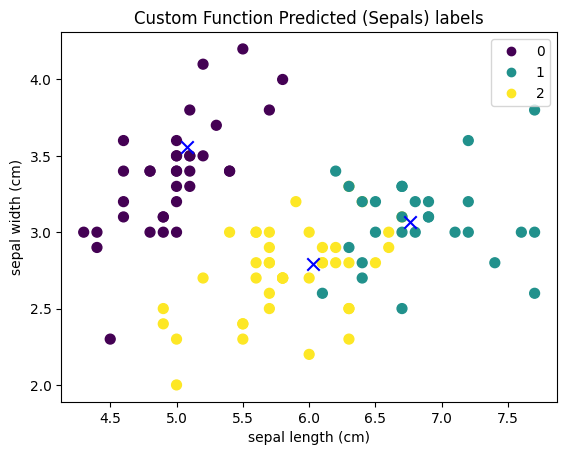

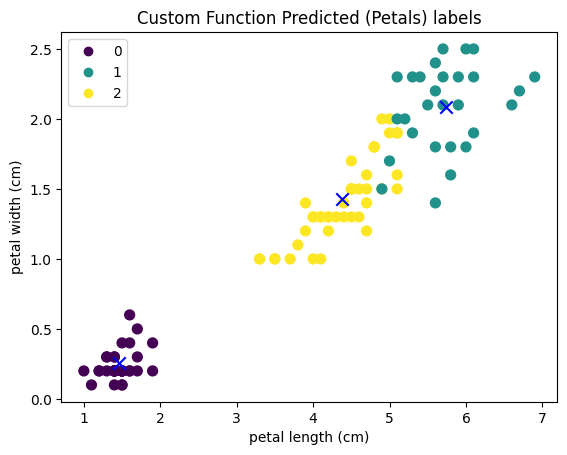

--- Part B: Comparing Custom vs Built-in ---
Custom predictions:   [2 2 1 2 0 2 0 2 0 1 0 0 2 2 2 0 1 2 0 2 2 0 2 2 0 2 0 2 2 1 1 0 2 1 0 0 2
 1 1 0 0 1 0 1 1 2 2 2 2 2 2 2 0 1 2 1 1 1 1 0 2 0 0 2 2 2 2 0 1 2 2 0 1 0
 1 2 1 0 2 2 0 1 0 2 1 0 0 2 1 2 1 0 1 1 0 1 1 2 0 0 2 0 2 0 0]
Built-in predictions: [2 2 1 2 0 2 0 2 0 1 0 0 2 2 2 0 1 2 0 2 2 0 2 2 0 2 0 2 2 1 1 0 2 1 0 0 2
 1 1 0 0 1 0 1 1 2 2 2 2 2 2 2 0 1 2 1 1 1 1 0 2 0 0 2 2 2 2 0 1 2 2 0 1 0
 1 2 1 0 2 2 0 1 0 2 1 0 0 2 1 2 1 0 1 1 0 1 1 2 0 0 2 0 2 0 0]

Result: The custom function matched the built-in algorithm on 105 out of 105 samples.
Accuracy match: 100.00%


In [ ]:
# %% Question 4 - Custom Prediction Function

# ---------------------------------------------------------
# The Prediction Function
# ---------------------------------------------------------
def custom_kmeans_predict(data, centroids):
    """
    Predicts the cluster label for each sample in 'data' based on
    the closest centroid using Euclidean distance.
    """
    # Calculate the distance from each point to each centroid
    # data[:, np.newaxis] broadcasts the array so we can subtract all centroids at once
    distances = np.linalg.norm(data[:, np.newaxis] - centroids, axis=2)

    # Return the index of the centroid with the minimum distance for each point
    return np.argmin(distances, axis=1)

# Ensure we have the built-in model trained on k=3 for comparison
k = 3
kmeans = KMeans(n_clusters=k, n_init=10).fit(trainData)
predCentroids = kmeans.cluster_centers_
built_in_predLabels = kmeans.predict(testData)

# Run our custom function
custom_predLabels = custom_kmeans_predict(testData, predCentroids)


# ---------------------------------------------------------
# a. Plot the predicted results on a scatter plot
# ---------------------------------------------------------
print("--- Part A: Plotting Custom Predictions ---")

# Plotting first two columns (Sepals)
plotData(testData, names, custom_predLabels, 0, 1, "Custom Function Predicted (Sepals)", predCentroids)

# Plotting last two columns (Petals)
plotData(testData, names, custom_predLabels, 2, 3, "Custom Function Predicted (Petals)", predCentroids)


# ---------------------------------------------------------
# b. Test the function by comparing to the built-in algorithm
# ---------------------------------------------------------
print("--- Part B: Comparing Custom vs Built-in ---")

# Check how many labels match exactly between the two arrays
matching_labels = np.sum(custom_predLabels == built_in_predLabels)
total_labels = len(testData)
match_percentage = (matching_labels / total_labels) * 100

print(f"Custom predictions:   {custom_predLabels}")
print(f"Built-in predictions: {built_in_predLabels}")
print(f"\nResult: The custom function matched the built-in algorithm on {matching_labels} out of {total_labels} samples.")
print(f"Accuracy match: {match_percentage:.2f}%")